In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "IMDB Dataset.csv"

df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "lakshmi25npathi/imdb-dataset-of-50k-movie-reviews",
  file_path,
)

print("First 5 records:", df.head())

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
First 5 records:                                               review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [ ]:
import numpy as np
import pandas as pd
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords, wordnet
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

In [ ]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
data = df.copy(deep=True)
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
data.shape

(50000, 2)

In [ ]:
data.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [ ]:
data.isnull().sum()

,0
review,0
sentiment,0


In [ ]:
stopwords = stopwords.words('english')
lemmatizer = WordNetLemmatizer()

def preprocess(text):
  text = text.lower()
  tokens = word_tokenize(text)
  tokens = [word for word in tokens if word.isalpha()]
  tokens = [word for word in tokens if word not in stopwords]
  tokens = [lemmatizer.lemmatize(word) for word in tokens]

  return " ".join(tokens)


data['clean_review'] = data['review'].apply(preprocess)
data.head()

,review,sentiment,clean_review
0,One of the other reviewers has mentioned that ...,positive,one reviewer mentioned watching oz episode hoo...
1,A wonderful little production. <br /><br />The...,positive,wonderful little production br br filming tech...
2,I thought this was a wonderful way to spend ti...,positive,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,negative,basically family little boy jake think zombie ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter mattei love time money visually stunnin...


In [ ]:
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(data['clean_review'])

In [ ]:
data['sentiment'] = data['sentiment'].map({'positive': 1, 'negative': 0})
y = data['sentiment']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(),
    "SVM": SVC(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier()
}

In [ ]:
results = []

for name, model in models.items():
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  accuracy = accuracy_score(y_test, y_pred)
  precision = precision_score(y_test, y_pred, average='weighted')
  recall = recall_score(y_test, y_pred, average='weighted')
  fl = f1_score(y_test, y_pred, average='weighted')
  results.append([name, accuracy, precision, recall, fl])

results

[['Naive Bayes', 0.8513, 0.8513411752875075, 0.8513, 0.8512867883523925],
 ['Logistic Regression',
  0.8859,
  0.8861496693847631,
  0.8859,
  0.8858679658550783],
 ['SVM', 0.8897, 0.8900390730715885, 0.8897, 0.8896609958579998],
 ['Random Forest', 0.8486, 0.8489148385488865, 0.8486, 0.8485862402043985],
 ['Gradient Boosting', 0.811, 0.8140976107607242, 0.811, 0.8104354309725426],
 ['XGBoost', 0.8601, 0.860628178974794, 0.8601, 0.8600228237064017]]

In [ ]:
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score'])
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.8513,0.851341,0.8513,0.851287
1,Logistic Regression,0.8859,0.886150,0.8859,0.885868
2,SVM,0.8897,0.890039,0.8897,0.889661
3,Random Forest,0.8486,0.848915,0.8486,0.848586
4,Gradient Boosting,0.8110,0.814098,0.8110,0.810435
5,XGBoost,0.8601,0.860628,0.8601,0.860023


<Figure size 1000x600 with 0 Axes>

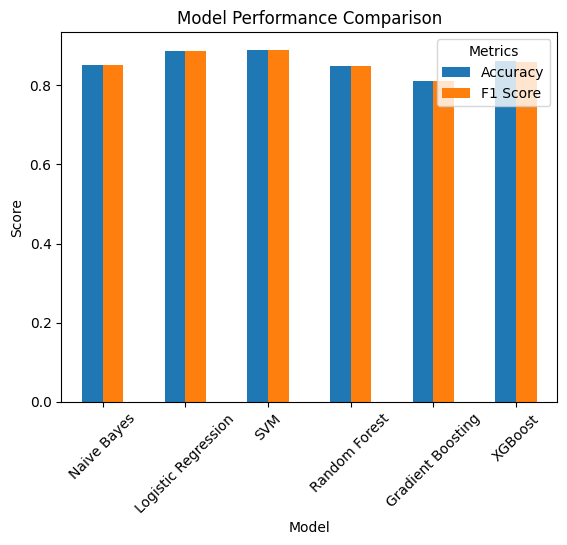

In [ ]:
plt.figure(figsize=(10, 6))
results_df.set_index('Model')[["Accuracy", "F1 Score"]].plot(kind='bar')
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(title='Metrics')
plt.show()

In [ ]:
model = MultinomialNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8513
Confusion Matrix:
 [[4186  775]
 [ 712 4327]]
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.84      0.85      4961
           1       0.85      0.86      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform

param_dist = {'alpha': uniform(loc=0, scale=1)}

random_search = RandomizedSearchCV(
    MultinomialNB(),
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best Score:", random_search.best_score_)

best_model = random_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

print("\n--- Tuned MultinomialNB Model Performance ---")
print("Accuracy (tuned model):", accuracy_score(y_test, y_pred_tuned))
print("Confusion Matrix (tuned model):\n", confusion_matrix(y_test, y_pred_tuned))
print("Classification Report (tuned model):\n", classification_report(y_test, y_pred_tuned))

Best Parameters: {'alpha': np.float64(0.9699098521619943)}
Best Score: 0.8531749999999999

--- Tuned MultinomialNB Model Performance ---
Accuracy (tuned model): 0.8512
Confusion Matrix (tuned model):
 [[4186  775]
 [ 713 4326]]
Classification Report (tuned model):
               precision    recall  f1-score   support

           0       0.85      0.84      0.85      4961
           1       0.85      0.86      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



In [ ]:
text = ["This movie was fantastic but uninspiring"]
clean = preprocess(text[0])
vector = vectorizer.transform([clean])
prediction = model.predict(vector)
print("Predicted Sentiment : ", prediction[0])

Predicted Sentiment :  1


In [ ]:
probabilities = model.predict_proba(vector)

class_labels = model.classes_

print("Predicted Probabilities:")
for i, prob in enumerate(probabilities[0]):
    print(f"  {class_labels[i]}: {prob:.4f}")

maxpred = np.argmax(probabilities[0])
predclass = class_labels[maxpred]
confidence = probabilities[0][maxpred]

print(f"\nPredicted Sentiment: {predclass} (Confidence: {confidence:.4f})")

Predicted Probabilities:
  0: 0.2125
  1: 0.7875

Predicted Sentiment: 1 (Confidence: 0.7875)


In [ ]:
import pandas as pd

# Initialize and train the XGBoost model
xgb_model = XGBClassifier()
print("Training XGBoost model...")
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

# Calculate metrics for XGBoost
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb, average='weighted')
recall_xgb = recall_score(y_test, y_pred_xgb, average='weighted')
f1_xgb = f1_score(y_test, y_pred_xgb, average='weighted')

# Append XGBoost results to the existing results list
results.append(["XGBoost", accuracy_xgb, precision_xgb, recall_xgb, f1_xgb])

# Recreate and display the updated results_df with XGBoost
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score'])
print("\nUpdated Model Performance Comparison with XGBoost:")
print(results_df)

Training XGBoost model...

Updated Model Performance Comparison with XGBoost:
                 Model  Accuracy  Precision  Recall  F1 Score
0          Naive Bayes    0.8513   0.851341  0.8513  0.851287
1  Logistic Regression    0.8859   0.886150  0.8859  0.885868
2                  SVM    0.8897   0.890039  0.8897  0.889661
3        Random Forest    0.8486   0.848915  0.8486  0.848586
4    Gradient Boosting    0.8110   0.814098  0.8110  0.810435
5              XGBoost    0.8601   0.860628  0.8601  0.860023
6              XGBoost    0.8601   0.860628  0.8601  0.860023


In [ ]:
import pickle
from google.colab import files

best_model_name = results_df.loc[results_df['Accuracy'].idxmax()]['Model']
best_model = models[best_model_name]

filename = f"{best_model_name.replace(' ', '_').lower()}_model.pkl"

with open(filename, 'wb') as file:
    pickle.dump(best_model, file)

print(f"The best model ({best_model_name}) has been saved to {filename}")

files.download(filename)

The best model (SVM) has been saved to svm_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>